# Decision bottlenecks
## Which constraint is costing the joint plan?
This is a **saved-observation feature experiment**, not a new match evaluation.
The staffing pilot stopped at seven accepted games when game eight exceeded
its latency limit. No result is invented for that game.

The representation measures exact conditional utility losses from removing a
worker or harvest, changing storage room, or taking the runner-up plan.
All comparisons use the same bounded legal route menu. Feature research is open.

In [1]:
%matplotlib inline
import json
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import plotly.express as px
import plotly.io as pio
from IPython.display import display

pio.renderers.default = "plotly_mimetype"
ROOT = Path.cwd() if (Path.cwd() / "reports").exists() else Path.cwd().parent
report = json.loads((ROOT / "reports/bottleneck_research.json").read_text())
assert report["base_assignment_parity_states"] == report["observations"] == 161
assert report["new_games"] == 0 and report["final_selected_features"] == 0
display(
    pd.DataFrame(
        [
            {
                "Saved observations": report["observations"],
                "Descriptor columns": report["candidate_columns"],
                "Varying": report["varying_columns"],
                "Constant": report["constant_columns"],
                "Selected for a final model": 0,
            }
        ]
    )
)

,Saved observations,Descriptor columns,Varying,Constant,Selected for a final model
0,161,39,28,11,0


## Marginal worker value
A removal value is the best retained-menu utility lost when that worker is
forced to PASS. This is **not hiring ROI**: it omits future production, an
alternative starting location, and the hire price. A worker can have zero
removal value when another worker can collect the same resource.
Rows below are explored development groups, not independent validation folds.

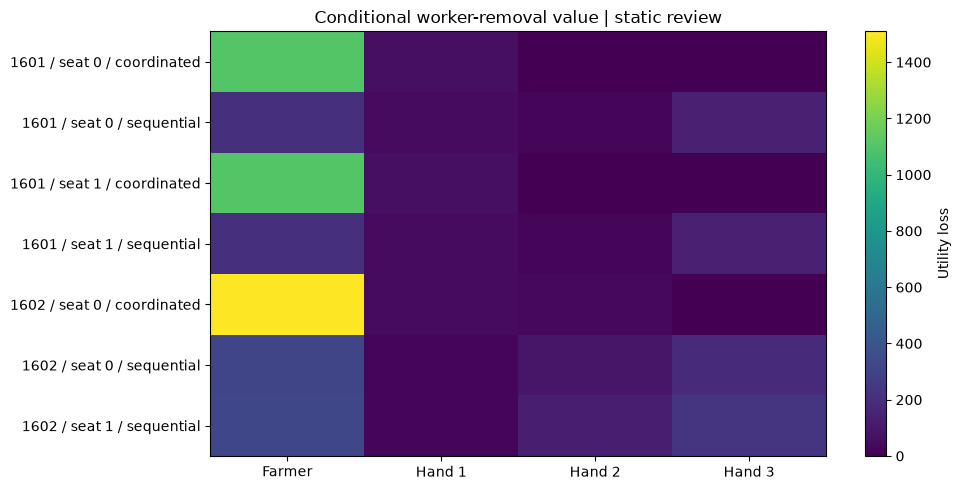

In [2]:
groups = pd.DataFrame(report["group_means"])
groups["group"] = (
    groups["seed"].astype(str) + " / seat " + groups["seat"].astype(str) + " / " + groups["arm"]
)
worker_cols = [f"bottleneck.worker{i}_removal_loss" for i in range(4)]
worker_values = groups.set_index("group")[worker_cols]
worker_values.columns = ["Farmer", "Hand 1", "Hand 2", "Hand 3"]
fig = px.imshow(
    worker_values,
    text_auto=".1f",
    aspect="auto",
    labels={"x": "Worker forced to PASS", "y": "Group", "color": "Utility loss"},
    title="Conditional worker-removal value",
    width=1050,
    height=520,
)
display(fig)
fig_static, ax = plt.subplots(figsize=(10, 5))
image = ax.imshow(worker_values.to_numpy(), aspect="auto")
ax.set_xticks(range(4), worker_values.columns)
ax.set_yticks(range(len(worker_values)), worker_values.index)
ax.set_title("Conditional worker-removal value | static review")
fig_static.colorbar(image, ax=ax, label="Utility loss")
fig_static.tight_layout()
plt.show()

## Coverage is a gate, not proof of feature value
The 39 columns include context and availability controls. Count constants and
redundancy instead of calling every generated column a novel predictive signal.
The original study has incomplete, latency-censored outcomes.
This audit measures no change in official match score.

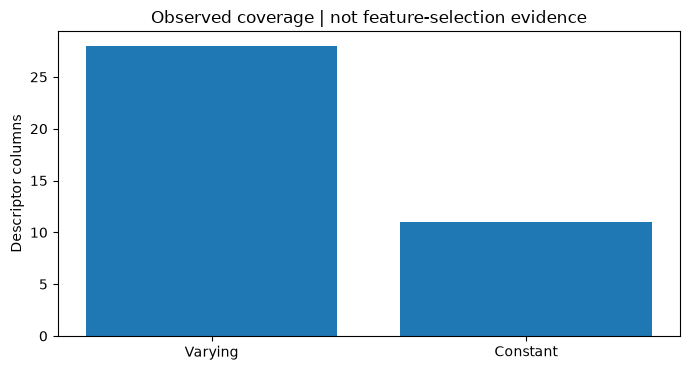

,max,median,p95
Extraction latency (ms),,,
0,69.608853,10.357762,20.014688


In [3]:
coverage = pd.Series(
    {
        "Varying": report["varying_columns"],
        "Constant": report["constant_columns"],
    },
    name="Columns",
)
fig = px.bar(
    x=coverage.index,
    y=coverage.values,
    labels={"x": "Observed coverage", "y": "Descriptor columns"},
    title="Representation coverage on 161 saved states",
    width=800,
    height=400,
)
display(fig)
fig_static, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(coverage.index, coverage.values)
ax.set_ylabel("Descriptor columns")
ax.set_title("Observed coverage | not feature-selection evidence")
fig_static.tight_layout()
plt.show()
timings = pd.DataFrame([report["latency_including_menu_ms"]])
display(timings.rename_axis("Extraction latency (ms)"))

## Decision and next controlled test
Keep feature research open. Use the observed worker and harvest bottlenecks to
prioritize option-selection ablations while holding staffing and market rules
equal between arms. Fit any learned threshold/ranker on development episode
groups only. Confirm on fresh development seeds and unrelated opponents before
untouched evaluation. Do not expand a family merely to increase column counts.

The current top leaderboard rating could not be retrieved in this session.
This representation is not claimed to beat that unverified rating.

**Sources:** `docs/bottleneck_research.md`, pinned route/game semantics, and
the exact source identities in the following execution record.

In [4]:
display(
    pd.DataFrame(
        [
            {
                "Source commit": report["source_commit"],
                "Original registration": report["registration_identity_sha256"],
                "Original pilot": report["original_pilot_status"],
                "Feature gate": report["feature_completion_gate"],
            }
        ]
    )
)
for limitation in report["limitations"]:
    print("- " + limitation)

,Source commit,Original registration,Original pilot,Feature gate
0,88a6f9d583af1325e508d2e0bd5623967ac1eb64,1402ba3cb622dab519c2c6ad8d5e609a162a68e41340cf...,HALTED_LATENCY_LIMIT,open_research


- Seven accepted episodes from a latency-censored eight-game development pilot
- Same retained route menu only; not global optimality or a valuation of unseen routes
- Capacity increases are hypothetical sensitivities, not purchasable game actions
- No fitted model or policy ablation; coverage and algebraic parity are not win-rate gains
- Seed 1601 was exercised in CI before original AWS registration
